## TR, T and P Analysis

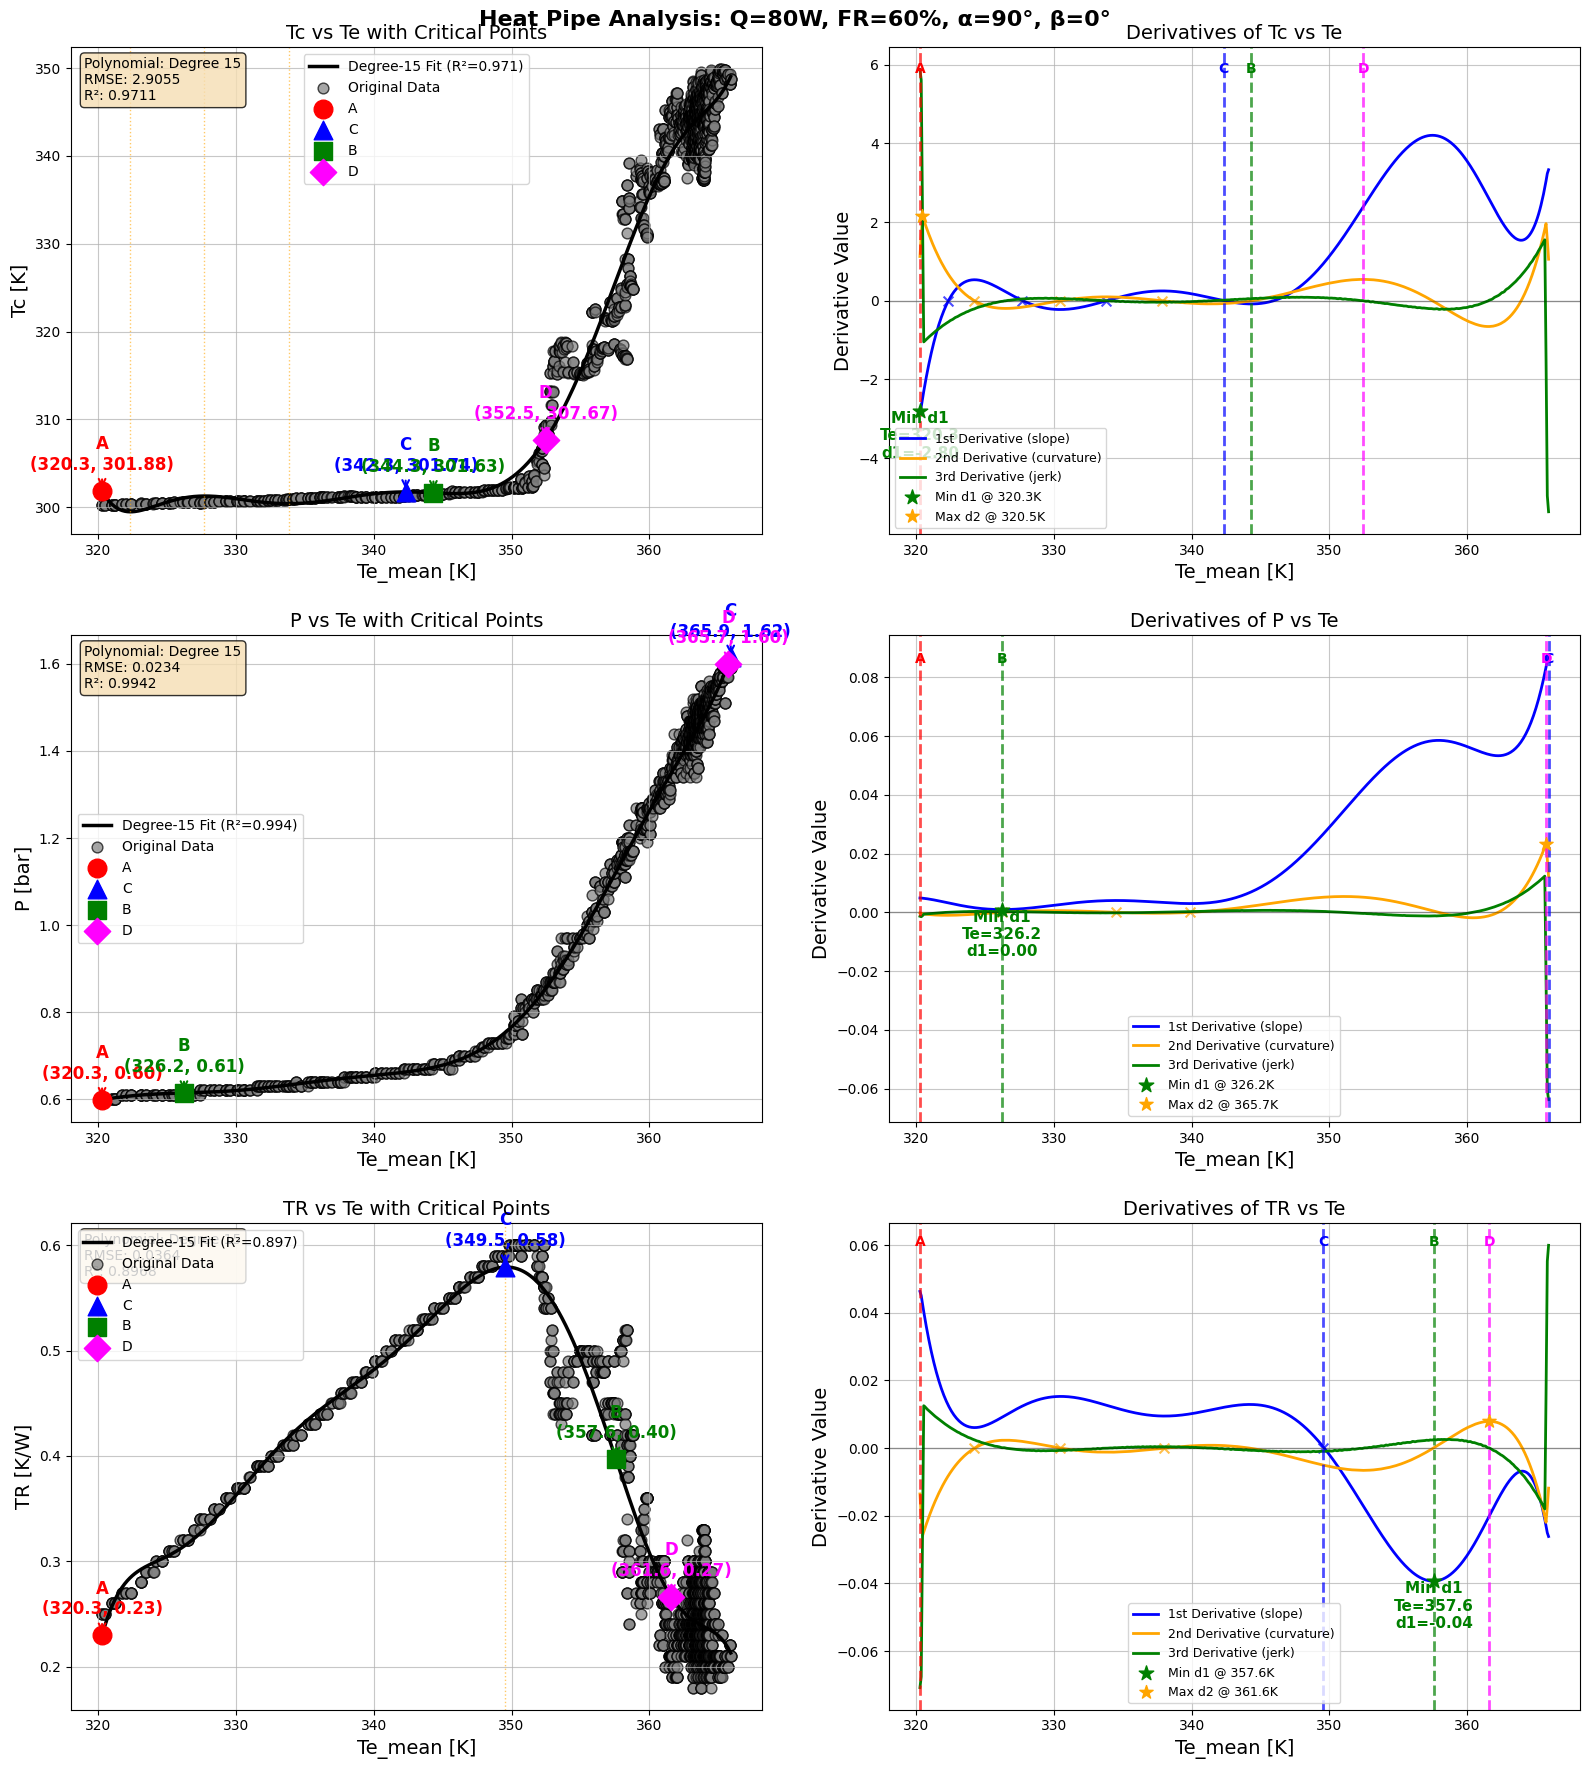

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import zscore
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

def optimize_polynomial_degree(Te, Y, max_degree=15, min_degree=5, cv_folds=5):
    degrees = range(min_degree, min(max_degree + 1, len(Te) // 3))
    rmse_scores, aic_scores, bic_scores, r2_scores = [], [], [], []
    Te_reshaped = Te.reshape(-1, 1)
    for degree in degrees:
        try:
            poly_pipeline = Pipeline([
                ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
                ('linear', LinearRegression())
            ])
            cv_scores = cross_val_score(poly_pipeline, Te_reshaped, Y, cv=min(cv_folds, len(Te)//2), scoring='neg_root_mean_squared_error')
            rmse_cv = -cv_scores.mean()
            rmse_scores.append(rmse_cv)
            poly_pipeline.fit(Te_reshaped, Y)
            Y_pred = poly_pipeline.predict(Te_reshaped)
            mse = mean_squared_error(Y, Y_pred)
            n = len(Y)
            k = degree + 1
            ss_res = np.sum((Y - Y_pred) ** 2)
            ss_tot = np.sum((Y - np.mean(Y)) ** 2)
            r2 = 1 - (ss_res / ss_tot)
            r2_scores.append(r2)
            aic = n * np.log(mse) + 2 * k
            bic = n * np.log(mse) + k * np.log(n)
            aic_scores.append(aic)
            bic_scores.append(bic)
        except Exception:
            rmse_scores.append(float('inf'))
            aic_scores.append(float('inf'))
            bic_scores.append(float('inf'))
            r2_scores.append(-float('inf'))
    degrees = np.array(degrees)
    rmse_scores = np.array(rmse_scores)
    aic_scores = np.array(aic_scores)
    bic_scores = np.array(bic_scores)
    r2_scores = np.array(r2_scores)
    valid_idx = np.isfinite(rmse_scores)
    if not np.any(valid_idx):
        return {'optimal_degree': 5, 'method': 'default', 'rmse': float('inf')}
    best_rmse_idx = np.argmin(rmse_scores[valid_idx])
    best_aic_idx = np.argmin(aic_scores[valid_idx])
    best_bic_idx = np.argmin(bic_scores[valid_idx])
    best_rmse_degree = degrees[valid_idx][best_rmse_idx]
    best_aic_degree = degrees[valid_idx][best_aic_idx]
    best_bic_degree = degrees[valid_idx][best_bic_idx]
    rmse_norm = (rmse_scores - np.min(rmse_scores[valid_idx])) / (np.max(rmse_scores[valid_idx]) - np.min(rmse_scores[valid_idx]) + 1e-10)
    aic_norm = (aic_scores - np.min(aic_scores[valid_idx])) / (np.max(aic_scores[valid_idx]) - np.min(aic_scores[valid_idx]) + 1e-10)
    composite_scores = 0.6 * rmse_norm + 0.4 * aic_norm
    best_composite_idx = np.argmin(composite_scores[valid_idx])
    best_composite_degree = degrees[valid_idx][best_composite_idx]
    optimal_degree = best_composite_degree
    optimal_rmse = rmse_scores[valid_idx][best_composite_idx]
    optimal_r2 = r2_scores[valid_idx][best_composite_idx]
    return {
        'optimal_degree': int(optimal_degree),
        'method': 'composite_score',
        'rmse': optimal_rmse,
        'r2': optimal_r2,
        'degrees_tested': degrees[valid_idx].tolist(),
        'rmse_scores': rmse_scores[valid_idx].tolist(),
        'aic_scores': aic_scores[valid_idx].tolist(),
        'bic_scores': bic_scores[valid_idx].tolist(),
        'best_rmse_degree': int(best_rmse_degree),
        'best_aic_degree': int(best_aic_degree),
        'best_bic_degree': int(best_bic_degree)
    }

def _find_zero_crossings(arr):
    zero_crossings = []
    for i in range(len(arr) - 1):
        if arr[i] * arr[i + 1] < 0:
            zero_crossings.append(i)
    return np.array(zero_crossings)

def _identify_critical_points(Te_fine, Y_fit, d1, d2, d3):
    # Point A: Always first, minimum Te
    point_A_idx = 0 if len(Te_fine) > 0 else None

    # Point C: 1st derivative zero and maximum Y, always second
    zero_crossings_d1 = _find_zero_crossings(d1)
    point_C_idx = None
    if len(zero_crossings_d1) > 0:
        point_C_idx = zero_crossings_d1[np.argmax(Y_fit[zero_crossings_d1])]
    else:
        point_C_idx = np.argmax(Y_fit)

    # Point B: 1st derivative is minimum and 2nd derivative is closer to zero or equal to zero. Always third, after C
    d1_min_idx = np.argmin(d1[point_C_idx+1:]) + point_C_idx + 1 if point_C_idx is not None and point_C_idx+1 < len(d1) else np.argmin(d1)
    d2_near_zero = np.argmin(np.abs(d2[point_C_idx+1:])) + point_C_idx + 1 if point_C_idx is not None and point_C_idx+1 < len(d2) else np.argmin(np.abs(d2))
    if abs(d2[d1_min_idx]) < 0.1:
        point_B_idx = d1_min_idx
    else:
        point_B_idx = d2_near_zero

    # Point D: 2nd derivative is maximum and 3rd derivative is closer to zero or equal to zero. Always last, after B
    d2_max_idx = np.argmax(d2[point_B_idx+1:]) + point_B_idx + 1 if point_B_idx is not None and point_B_idx+1 < len(d2) else np.argmax(d2)
    d3_near_zero = np.argmin(np.abs(d3[point_B_idx+1:])) + point_B_idx + 1 if point_B_idx is not None and point_B_idx+1 < len(d3) else np.argmin(np.abs(d3))
    if abs(d3[d2_max_idx]) < 0.1:
        point_D_idx = d2_max_idx
    else:
        point_D_idx = d3_near_zero

    # Sequence: A, C, B, D from Te_min to Te_max
    return {
        'A': point_A_idx,
        'C': point_C_idx,
        'B': point_B_idx,
        'D': point_D_idx
    }

def _analyze_relationship(df, y_col, poly_deg, y_label, y_unit, max_poly_deg=15, min_poly_deg=2):
    df_sorted = df.sort_values('Te_mean[K]')
    Te = df_sorted['Te_mean[K]'].values
    Y = df_sorted[y_col].values
    try:
        coeffs = np.polyfit(Te, Y, deg=poly_deg)
        poly = np.poly1d(coeffs)
        Te_fine = np.linspace(Te.min(), Te.max(), 500)
        Y_fit = poly(Te_fine)
        Y_pred_original = poly(Te)
        rmse = np.sqrt(mean_squared_error(Y, Y_pred_original))
        ss_res = np.sum((Y - Y_pred_original) ** 2)
        ss_tot = np.sum((Y - np.mean(Y)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
    except Exception:
        poly_deg = 3
        coeffs = np.polyfit(Te, Y, deg=poly_deg)
        poly = np.poly1d(coeffs)
        Te_fine = np.linspace(Te.min(), Te.max(), 500)
        Y_fit = poly(Te_fine)
        Y_pred_original = poly(Te)
        rmse = np.sqrt(mean_squared_error(Y, Y_pred_original))
        ss_res = np.sum((Y - Y_pred_original) ** 2)
        ss_tot = np.sum((Y - np.mean(Y)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
    d1 = np.gradient(Y_fit, Te_fine)
    d2 = np.gradient(d1, Te_fine)
    d3 = np.gradient(d2, Te_fine)
    points = _identify_critical_points(Te_fine, Y_fit, d1, d2, d3)
    return {
        'Te_original': Te,
        'Y_original': Y,
        'Te_fine': Te_fine,
        'Y_fit': Y_fit,
        'd1': d1,
        'd2': d2,
        'd3': d3,
        'points': points,
        'poly_coeffs': coeffs,
        'poly_degree': poly_deg,
        'rmse': rmse,
        'r2': r2,
        'y_label': y_label,
        'y_unit': y_unit
    }

def analyze_heat_pipe_data(csv_path, Q, FR, alpha, beta, te_min, te_max, poly_deg='auto', outlier_threshold=2.5, max_poly_deg=15, min_poly_deg=2):
    df = pd.read_csv(csv_path)
    df_sel = df[(df['Q[W]'] == Q) & (df['FR[%]'] == FR) & (df['alpha'] == alpha) & (df['beta'] == beta)]
    df_filtered = df_sel[(df_sel['Te_mean[K]'] >= te_min) & (df_sel['Te_mean[K]'] <= te_max)].copy()
    if df_filtered.empty:
        print("No data found for given condition and range.")
        return None
    results = {}
    # Tc analysis
    df_tc_clean = df_filtered[np.abs(zscore(df_filtered['Tc_mean[K]'])) < outlier_threshold]
    if len(df_tc_clean) > min_poly_deg:
        Te_tc = df_tc_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
        Tc_tc = df_tc_clean.sort_values('Te_mean[K]')['Tc_mean[K]'].values
        tc_poly_deg = poly_deg
        if poly_deg == 'auto':
            tc_opt_result = optimize_polynomial_degree(Te_tc, Tc_tc, max_poly_deg, min_poly_deg)
            tc_poly_deg = tc_opt_result['optimal_degree']
        results['tc_analysis'] = _analyze_relationship(
            df_tc_clean, 'Tc_mean[K]', tc_poly_deg, 'Tc', 'K', max_poly_deg, min_poly_deg
        )
    # P analysis
    df_p_clean = df_filtered[np.abs(zscore(df_filtered['P[bar]'])) < outlier_threshold]
    if len(df_p_clean) > min_poly_deg:
        Te_p = df_p_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
        P_p = df_p_clean.sort_values('Te_mean[K]')['P[bar]'].values
        p_poly_deg = poly_deg
        if poly_deg == 'auto':
            p_opt_result = optimize_polynomial_degree(Te_p, P_p, max_poly_deg, min_poly_deg)
            p_poly_deg = p_opt_result['optimal_degree']
        results['p_analysis'] = _analyze_relationship(
            df_p_clean, 'P[bar]', p_poly_deg, 'P', 'bar', max_poly_deg, min_poly_deg
        )
    # TR analysis
    if 'TR[K/W]' in df_filtered.columns:
        df_tr_clean = df_filtered[np.abs(zscore(df_filtered['TR[K/W]'])) < outlier_threshold]
        if len(df_tr_clean) > min_poly_deg:
            Te_tr = df_tr_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
            TR_tr = df_tr_clean.sort_values('Te_mean[K]')['TR[K/W]'].values
            tr_poly_deg = poly_deg
            if poly_deg == 'auto':
                tr_opt_result = optimize_polynomial_degree(Te_tr, TR_tr, max_poly_deg, min_poly_deg)
                tr_poly_deg = tr_opt_result['optimal_degree']
            results['tr_analysis'] = _analyze_relationship(
                df_tr_clean, 'TR[K/W]', tr_poly_deg, 'TR', 'K/W', max_poly_deg, min_poly_deg
            )
    _create_comprehensive_plots(results, Q, FR, alpha, beta)
    return results

def _create_comprehensive_plots(results, Q, FR, alpha, beta):
    n_plots = len(results)
    fig, axes = plt.subplots(n_plots, 2, figsize=(16, 6 * n_plots))
    fig.suptitle(f'Heat Pipe Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    for plot_idx, (analysis_type, data) in enumerate(results.items()):
        if data is None:
            continue
        ax1 = axes[plot_idx, 0] if n_plots > 1 else axes[0]
        poly_deg = data.get('poly_degree', 'Unknown')
        rmse = data.get('rmse', 0)
        r2 = data.get('r2', 0)
        ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Degree-{poly_deg} Fit (R²={r2:.3f})')
        ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label='Original Data')
        fit_text = f'Polynomial: Degree {poly_deg}\nRMSE: {rmse:.4f}\nR²: {r2:.4f}'
        ax1.text(0.02, 0.98, fit_text, transform=ax1.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        for label, idx in data['points'].items():
            ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{label}')
            ax1.annotate(f'{label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
        zero_crossings_d1 = _find_zero_crossings(data['d1'])
        zero_crossings_d2 = _find_zero_crossings(data['d2'])
        for zc in zero_crossings_d1[:3]:
            ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
        ax1.set_xlabel('Te_mean [K]', fontsize=14)
        ax1.set_ylabel(f'{data["y_label"]} [{data["y_unit"]}]', fontsize=14)
        ax1.set_title(f'{data["y_label"]} vs Te with Critical Points', fontsize=14)
        ax1.legend(fontsize=10, loc='best')
        ax1.grid(True, alpha=0.7)
        ax2 = axes[plot_idx, 1] if n_plots > 1 else axes[1]
        ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
        ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
        ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
        for label, idx in data['points'].items():
            ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
            ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, label, color=colors[label], fontweight='bold', ha='center')
        min_d1_idx = np.argmin(data['d1'])
        ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
        ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
        max_d1_idx = np.argmax(data['d1'])
        max_d2_idx = np.argmax(data['d2'])
        max_d3_idx = np.argmax(np.abs(data['d3']))
        ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
        for zc in zero_crossings_d1[:3]:
            ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
        for zc in zero_crossings_d2[:3]:
            ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)
        ax2.set_xlabel('Te_mean [K]', fontsize=14)
        ax2.set_ylabel('Derivative Value', fontsize=14)
        ax2.set_title(f'Derivatives of {data["y_label"]} vs Te', fontsize=14)
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# Example usage:
csv_path = 'database.csv'
Q, FR, alpha, beta = 80, 60, 90, 0
te_min, te_max = 320, 390
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=3
)

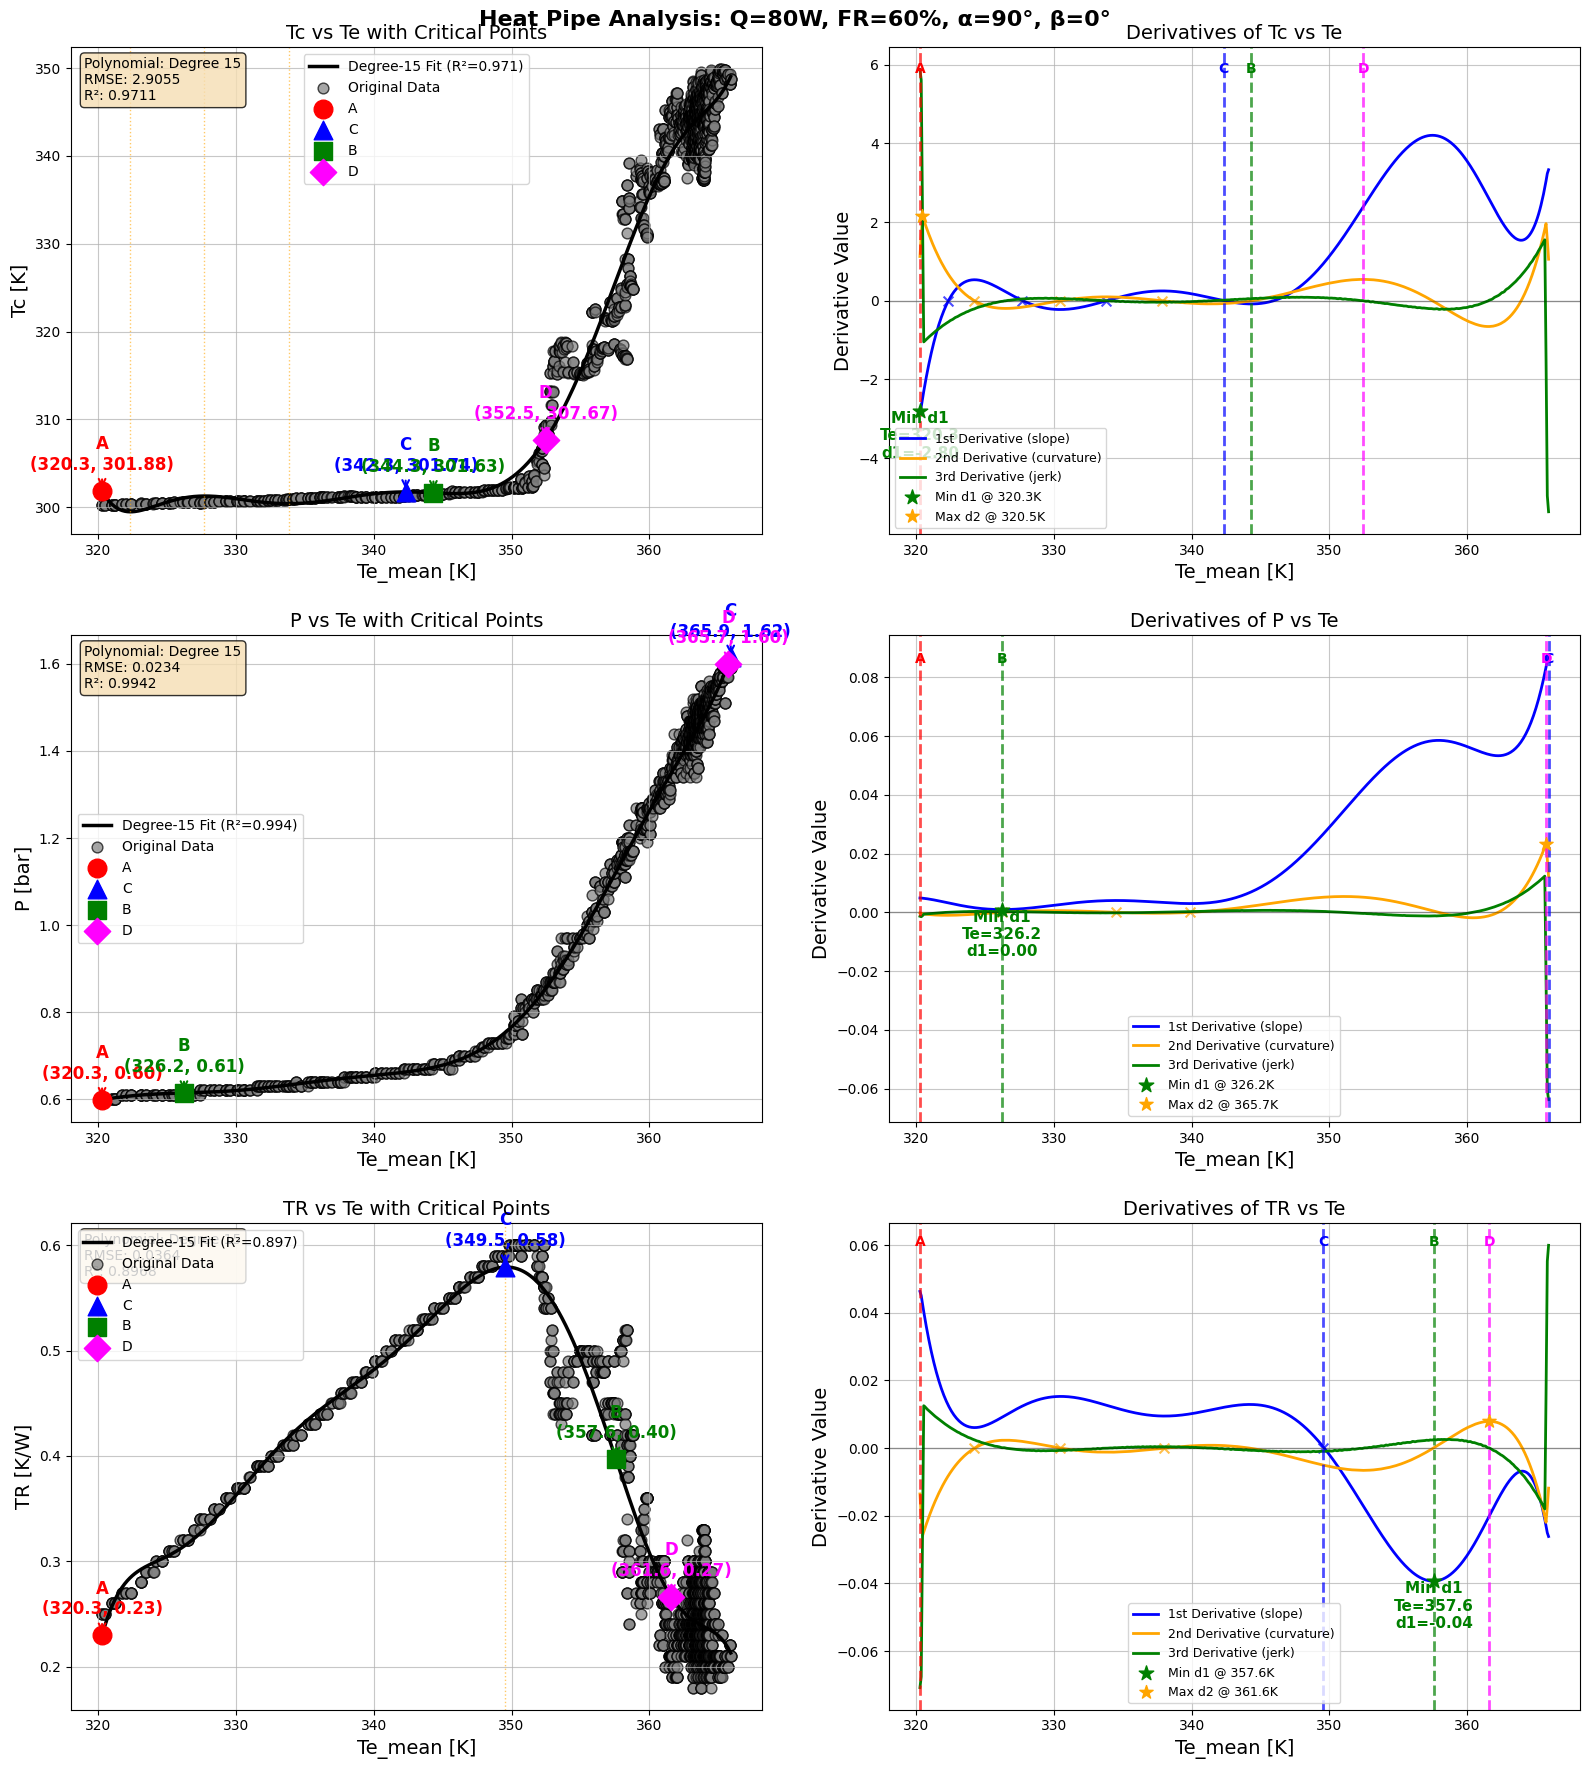

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import zscore
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

def optimize_polynomial_degree(Te, Y, max_degree=15, min_degree=5, cv_folds=5):
    degrees = range(min_degree, min(max_degree + 1, len(Te) // 3))
    rmse_scores, aic_scores, bic_scores, r2_scores = [], [], [], []
    Te_reshaped = Te.reshape(-1, 1)
    for degree in degrees:
        try:
            poly_pipeline = Pipeline([
                ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
                ('linear', LinearRegression())
            ])
            cv_scores = cross_val_score(poly_pipeline, Te_reshaped, Y, cv=min(cv_folds, len(Te)//2), scoring='neg_root_mean_squared_error')
            rmse_cv = -cv_scores.mean()
            rmse_scores.append(rmse_cv)
            poly_pipeline.fit(Te_reshaped, Y)
            Y_pred = poly_pipeline.predict(Te_reshaped)
            mse = mean_squared_error(Y, Y_pred)
            n = len(Y)
            k = degree + 1
            ss_res = np.sum((Y - Y_pred) ** 2)
            ss_tot = np.sum((Y - np.mean(Y)) ** 2)
            r2 = 1 - (ss_res / ss_tot)
            r2_scores.append(r2)
            aic = n * np.log(mse) + 2 * k
            bic = n * np.log(mse) + k * np.log(n)
            aic_scores.append(aic)
            bic_scores.append(bic)
        except Exception:
            rmse_scores.append(float('inf'))
            aic_scores.append(float('inf'))
            bic_scores.append(float('inf'))
            r2_scores.append(-float('inf'))
    degrees = np.array(degrees)
    rmse_scores = np.array(rmse_scores)
    aic_scores = np.array(aic_scores)
    bic_scores = np.array(bic_scores)
    r2_scores = np.array(r2_scores)
    valid_idx = np.isfinite(rmse_scores)
    if not np.any(valid_idx):
        return {'optimal_degree': 5, 'method': 'default', 'rmse': float('inf')}
    best_rmse_idx = np.argmin(rmse_scores[valid_idx])
    best_aic_idx = np.argmin(aic_scores[valid_idx])
    best_bic_idx = np.argmin(bic_scores[valid_idx])
    best_rmse_degree = degrees[valid_idx][best_rmse_idx]
    best_aic_degree = degrees[valid_idx][best_aic_idx]
    best_bic_degree = degrees[valid_idx][best_bic_idx]
    rmse_norm = (rmse_scores - np.min(rmse_scores[valid_idx])) / (np.max(rmse_scores[valid_idx]) - np.min(rmse_scores[valid_idx]) + 1e-10)
    aic_norm = (aic_scores - np.min(aic_scores[valid_idx])) / (np.max(aic_scores[valid_idx]) - np.min(aic_scores[valid_idx]) + 1e-10)
    composite_scores = 0.6 * rmse_norm + 0.4 * aic_norm
    best_composite_idx = np.argmin(composite_scores[valid_idx])
    best_composite_degree = degrees[valid_idx][best_composite_idx]
    optimal_degree = best_composite_degree
    optimal_rmse = rmse_scores[valid_idx][best_composite_idx]
    optimal_r2 = r2_scores[valid_idx][best_composite_idx]
    return {
        'optimal_degree': int(optimal_degree),
        'method': 'composite_score',
        'rmse': optimal_rmse,
        'r2': optimal_r2,
        'degrees_tested': degrees[valid_idx].tolist(),
        'rmse_scores': rmse_scores[valid_idx].tolist(),
        'aic_scores': aic_scores[valid_idx].tolist(),
        'bic_scores': bic_scores[valid_idx].tolist(),
        'best_rmse_degree': int(best_rmse_degree),
        'best_aic_degree': int(best_aic_degree),
        'best_bic_degree': int(best_bic_degree)
    }

def _find_zero_crossings(arr):
    zero_crossings = []
    for i in range(len(arr) - 1):
        if arr[i] * arr[i + 1] < 0:
            zero_crossings.append(i)
    return np.array(zero_crossings)

def _identify_critical_points(Te_fine, Y_fit, d1, d2, d3):
    # Point A: Always first, minimum Te
    point_A_idx = 0 if len(Te_fine) > 0 else None

    # Point C: 1st derivative zero and maximum Y, always second
    zero_crossings_d1 = _find_zero_crossings(d1)
    point_C_idx = None
    if len(zero_crossings_d1) > 0:
        point_C_idx = zero_crossings_d1[np.argmax(Y_fit[zero_crossings_d1])]
    else:
        point_C_idx = np.argmax(Y_fit)

    # Point B: 1st derivative is minimum and 2nd derivative is closer to zero or equal to zero. Always third, after C
    d1_min_idx = np.argmin(d1[point_C_idx+1:]) + point_C_idx + 1 if point_C_idx is not None and point_C_idx+1 < len(d1) else np.argmin(d1)
    d2_near_zero = np.argmin(np.abs(d2[point_C_idx+1:])) + point_C_idx + 1 if point_C_idx is not None and point_C_idx+1 < len(d2) else np.argmin(np.abs(d2))
    if abs(d2[d1_min_idx]) < 0.1:
        point_B_idx = d1_min_idx
    else:
        point_B_idx = d2_near_zero

    # Point D: 2nd derivative is maximum and 3rd derivative is closer to zero or equal to zero. Always last, after B
    d2_max_idx = np.argmax(d2[point_B_idx+1:]) + point_B_idx + 1 if point_B_idx is not None and point_B_idx+1 < len(d2) else np.argmax(d2)
    d3_near_zero = np.argmin(np.abs(d3[point_B_idx+1:])) + point_B_idx + 1 if point_B_idx is not None and point_B_idx+1 < len(d3) else np.argmin(np.abs(d3))
    if abs(d3[d2_max_idx]) < 0.1:
        point_D_idx = d2_max_idx
    else:
        point_D_idx = d3_near_zero

    # Sequence: A, C, B, D from Te_min to Te_max
    return {
        'A': point_A_idx,
        'C': point_C_idx,
        'B': point_B_idx,
        'D': point_D_idx
    }

def _analyze_relationship(df, y_col, poly_deg, y_label, y_unit, max_poly_deg=15, min_poly_deg=2):
    df_sorted = df.sort_values('Te_mean[K]')
    Te = df_sorted['Te_mean[K]'].values
    Y = df_sorted[y_col].values
    try:
        coeffs = np.polyfit(Te, Y, deg=poly_deg)
        poly = np.poly1d(coeffs)
        Te_fine = np.linspace(Te.min(), Te.max(), 500)
        Y_fit = poly(Te_fine)
        Y_pred_original = poly(Te)
        rmse = np.sqrt(mean_squared_error(Y, Y_pred_original))
        ss_res = np.sum((Y - Y_pred_original) ** 2)
        ss_tot = np.sum((Y - np.mean(Y)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
    except Exception:
        poly_deg = 3
        coeffs = np.polyfit(Te, Y, deg=poly_deg)
        poly = np.poly1d(coeffs)
        Te_fine = np.linspace(Te.min(), Te.max(), 500)
        Y_fit = poly(Te_fine)
        Y_pred_original = poly(Te)
        rmse = np.sqrt(mean_squared_error(Y, Y_pred_original))
        ss_res = np.sum((Y - Y_pred_original) ** 2)
        ss_tot = np.sum((Y - np.mean(Y)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
    d1 = np.gradient(Y_fit, Te_fine)
    d2 = np.gradient(d1, Te_fine)
    d3 = np.gradient(d2, Te_fine)
    points = _identify_critical_points(Te_fine, Y_fit, d1, d2, d3)
    return {
        'Te_original': Te,
        'Y_original': Y,
        'Te_fine': Te_fine,
        'Y_fit': Y_fit,
        'd1': d1,
        'd2': d2,
        'd3': d3,
        'points': points,
        'poly_coeffs': coeffs,
        'poly_degree': poly_deg,
        'rmse': rmse,
        'r2': r2,
        'y_label': y_label,
        'y_unit': y_unit
    }

def analyze_heat_pipe_data(csv_path, Q, FR, alpha, beta, te_min, te_max, poly_deg='auto', outlier_threshold=2.5, max_poly_deg=15, min_poly_deg=2):
    df = pd.read_csv(csv_path)
    df_sel = df[(df['Q[W]'] == Q) & (df['FR[%]'] == FR) & (df['alpha'] == alpha) & (df['beta'] == beta)]
    df_filtered = df_sel[(df_sel['Te_mean[K]'] >= te_min) & (df_sel['Te_mean[K]'] <= te_max)].copy()
    if df_filtered.empty:
        print("No data found for given condition and range.")
        return None
    results = {}
    # Tc analysis
    df_tc_clean = df_filtered[np.abs(zscore(df_filtered['Tc_mean[K]'])) < outlier_threshold]
    if len(df_tc_clean) > min_poly_deg:
        Te_tc = df_tc_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
        Tc_tc = df_tc_clean.sort_values('Te_mean[K]')['Tc_mean[K]'].values
        tc_poly_deg = poly_deg
        if poly_deg == 'auto':
            tc_opt_result = optimize_polynomial_degree(Te_tc, Tc_tc, max_poly_deg, min_poly_deg)
            tc_poly_deg = tc_opt_result['optimal_degree']
        results['tc_analysis'] = _analyze_relationship(
            df_tc_clean, 'Tc_mean[K]', tc_poly_deg, 'Tc', 'K', max_poly_deg, min_poly_deg
        )
    # P analysis
    df_p_clean = df_filtered[np.abs(zscore(df_filtered['P[bar]'])) < outlier_threshold]
    if len(df_p_clean) > min_poly_deg:
        Te_p = df_p_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
        P_p = df_p_clean.sort_values('Te_mean[K]')['P[bar]'].values
        p_poly_deg = poly_deg
        if poly_deg == 'auto':
            p_opt_result = optimize_polynomial_degree(Te_p, P_p, max_poly_deg, min_poly_deg)
            p_poly_deg = p_opt_result['optimal_degree']
        results['p_analysis'] = _analyze_relationship(
            df_p_clean, 'P[bar]', p_poly_deg, 'P', 'bar', max_poly_deg, min_poly_deg
        )
    # TR analysis
    if 'TR[K/W]' in df_filtered.columns:
        df_tr_clean = df_filtered[np.abs(zscore(df_filtered['TR[K/W]'])) < outlier_threshold]
        if len(df_tr_clean) > min_poly_deg:
            Te_tr = df_tr_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
            TR_tr = df_tr_clean.sort_values('Te_mean[K]')['TR[K/W]'].values
            tr_poly_deg = poly_deg
            if poly_deg == 'auto':
                tr_opt_result = optimize_polynomial_degree(Te_tr, TR_tr, max_poly_deg, min_poly_deg)
                tr_poly_deg = tr_opt_result['optimal_degree']
            results['tr_analysis'] = _analyze_relationship(
                df_tr_clean, 'TR[K/W]', tr_poly_deg, 'TR', 'K/W', max_poly_deg, min_poly_deg
            )
    _create_comprehensive_plots(results, Q, FR, alpha, beta)
    return results

def _create_comprehensive_plots(results, Q, FR, alpha, beta):
    n_plots = len(results)
    fig, axes = plt.subplots(n_plots, 2, figsize=(16, 6 * n_plots))
    fig.suptitle(f'Heat Pipe Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    for plot_idx, (analysis_type, data) in enumerate(results.items()):
        if data is None:
            continue
        ax1 = axes[plot_idx, 0] if n_plots > 1 else axes[0]
        poly_deg = data.get('poly_degree', 'Unknown')
        rmse = data.get('rmse', 0)
        r2 = data.get('r2', 0)
        ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Degree-{poly_deg} Fit (R²={r2:.3f})')
        ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label='Original Data')
        fit_text = f'Polynomial: Degree {poly_deg}\nRMSE: {rmse:.4f}\nR²: {r2:.4f}'
        ax1.text(0.02, 0.98, fit_text, transform=ax1.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        for label, idx in data['points'].items():
            ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{label}')
            ax1.annotate(f'{label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
        zero_crossings_d1 = _find_zero_crossings(data['d1'])
        zero_crossings_d2 = _find_zero_crossings(data['d2'])
        for zc in zero_crossings_d1[:3]:
            ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
        ax1.set_xlabel('Te_mean [K]', fontsize=14)
        ax1.set_ylabel(f'{data["y_label"]} [{data["y_unit"]}]', fontsize=14)
        ax1.set_title(f'{data["y_label"]} vs Te with Critical Points', fontsize=14)
        ax1.legend(fontsize=10, loc='best')
        ax1.grid(True, alpha=0.7)
        ax2 = axes[plot_idx, 1] if n_plots > 1 else axes[1]
        ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
        ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
        ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
        for label, idx in data['points'].items():
            ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
            ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, label, color=colors[label], fontweight='bold', ha='center')
        min_d1_idx = np.argmin(data['d1'])
        ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
        ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
        max_d1_idx = np.argmax(data['d1'])
        max_d2_idx = np.argmax(data['d2'])
        max_d3_idx = np.argmax(np.abs(data['d3']))
        ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
        for zc in zero_crossings_d1[:3]:
            ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
        for zc in zero_crossings_d2[:3]:
            ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)
        ax2.set_xlabel('Te_mean [K]', fontsize=14)
        ax2.set_ylabel('Derivative Value', fontsize=14)
        ax2.set_title(f'Derivatives of {data["y_label"]} vs Te', fontsize=14)
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# Example usage:
csv_path = 'database.csv'
Q, FR, alpha, beta = 80, 60, 90, 0
te_min, te_max = 320, 390
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=3
)

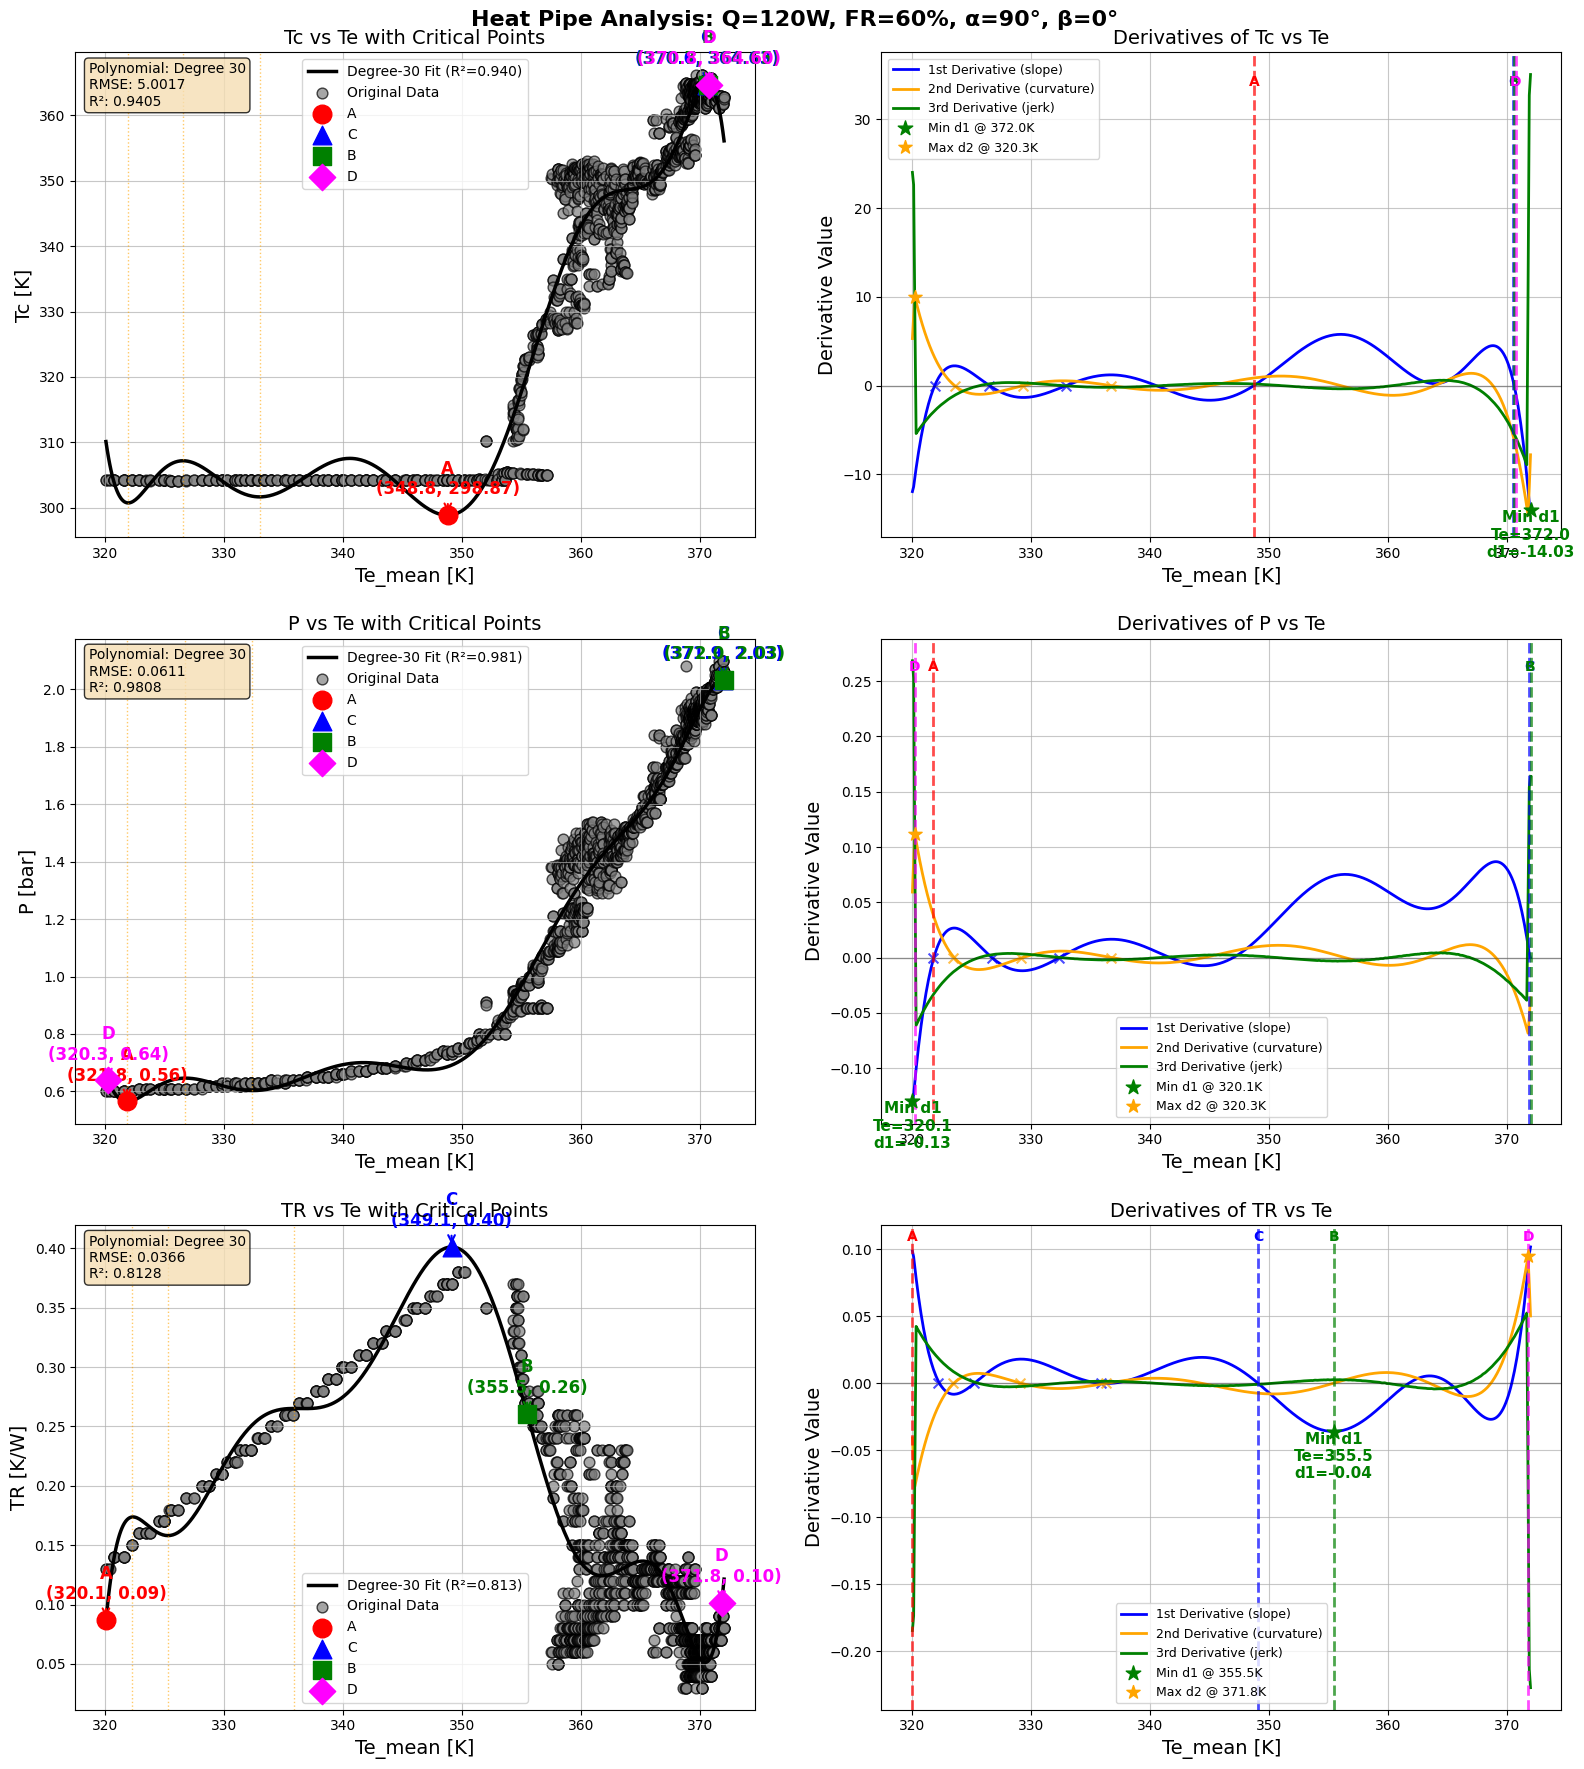

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import zscore
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

def optimize_polynomial_degree(Te, Y, max_degree=15, min_degree=5, cv_folds=5):
    degrees = range(min_degree, min(max_degree + 1, len(Te) // 3))
    rmse_scores, aic_scores, bic_scores, r2_scores = [], [], [], []
    Te_reshaped = Te.reshape(-1, 1)
    for degree in degrees:
        try:
            poly_pipeline = Pipeline([
                ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
                ('linear', LinearRegression())
            ])
            cv_scores = cross_val_score(poly_pipeline, Te_reshaped, Y, cv=min(cv_folds, len(Te)//2), scoring='neg_root_mean_squared_error')
            rmse_cv = -cv_scores.mean()
            rmse_scores.append(rmse_cv)
            poly_pipeline.fit(Te_reshaped, Y)
            Y_pred = poly_pipeline.predict(Te_reshaped)
            mse = mean_squared_error(Y, Y_pred)
            n = len(Y)
            k = degree + 1
            ss_res = np.sum((Y - Y_pred) ** 2)
            ss_tot = np.sum((Y - np.mean(Y)) ** 2)
            r2 = 1 - (ss_res / ss_tot)
            r2_scores.append(r2)
            aic = n * np.log(mse) + 2 * k
            bic = n * np.log(mse) + k * np.log(n)
            aic_scores.append(aic)
            bic_scores.append(bic)
        except Exception:
            rmse_scores.append(float('inf'))
            aic_scores.append(float('inf'))
            bic_scores.append(float('inf'))
            r2_scores.append(-float('inf'))
    degrees = np.array(degrees)
    rmse_scores = np.array(rmse_scores)
    aic_scores = np.array(aic_scores)
    bic_scores = np.array(bic_scores)
    r2_scores = np.array(r2_scores)
    valid_idx = np.isfinite(rmse_scores)
    if not np.any(valid_idx):
        return {'optimal_degree': 5, 'method': 'default', 'rmse': float('inf')}
    best_rmse_idx = np.argmin(rmse_scores[valid_idx])
    best_aic_idx = np.argmin(aic_scores[valid_idx])
    best_bic_idx = np.argmin(bic_scores[valid_idx])
    best_rmse_degree = degrees[valid_idx][best_rmse_idx]
    best_aic_degree = degrees[valid_idx][best_aic_idx]
    best_bic_degree = degrees[valid_idx][best_bic_idx]
    rmse_norm = (rmse_scores - np.min(rmse_scores[valid_idx])) / (np.max(rmse_scores[valid_idx]) - np.min(rmse_scores[valid_idx]) + 1e-10)
    aic_norm = (aic_scores - np.min(aic_scores[valid_idx])) / (np.max(aic_scores[valid_idx]) - np.min(aic_scores[valid_idx]) + 1e-10)
    composite_scores = 0.6 * rmse_norm + 0.4 * aic_norm
    best_composite_idx = np.argmin(composite_scores[valid_idx])
    best_composite_degree = degrees[valid_idx][best_composite_idx]
    optimal_degree = best_composite_degree
    optimal_rmse = rmse_scores[valid_idx][best_composite_idx]
    optimal_r2 = r2_scores[valid_idx][best_composite_idx]
    return {
        'optimal_degree': int(optimal_degree),
        'method': 'composite_score',
        'rmse': optimal_rmse,
        'r2': optimal_r2,
        'degrees_tested': degrees[valid_idx].tolist(),
        'rmse_scores': rmse_scores[valid_idx].tolist(),
        'aic_scores': aic_scores[valid_idx].tolist(),
        'bic_scores': bic_scores[valid_idx].tolist(),
        'best_rmse_degree': int(best_rmse_degree),
        'best_aic_degree': int(best_aic_degree),
        'best_bic_degree': int(best_bic_degree)
    }

def _find_zero_crossings(arr):
    zero_crossings = []
    for i in range(len(arr) - 1):
        if arr[i] * arr[i + 1] < 0:
            zero_crossings.append(i)
    return np.array(zero_crossings)

# --- Tc/P vs Te critical point logic ---
def _identify_critical_points_tc_p(Te_fine, Y_fit, d1, d2, d3):
    # Point A: minimum function value (start)
    point_A_idx = np.argmin(Y_fit)
    # Point C: zero crossing of d1 with max Y
    zero_crossings_d1 = _find_zero_crossings(d1)
    if len(zero_crossings_d1) > 0:
        point_C_idx = zero_crossings_d1[np.argmax(Y_fit[zero_crossings_d1])]
    else:
        point_C_idx = np.argmax(Y_fit)
    # Point B: min d1, d2 near zero, after C
    d1_min_idx = np.argmin(d1[point_C_idx+1:]) + point_C_idx + 1 if point_C_idx+1 < len(d1) else np.argmin(d1)
    d2_near_zero = np.argmin(np.abs(d2[point_C_idx+1:])) + point_C_idx + 1 if point_C_idx+1 < len(d2) else np.argmin(np.abs(d2))
    if abs(d2[d1_min_idx]) < 0.1:
        point_B_idx = d1_min_idx
    else:
        point_B_idx = d2_near_zero
    # Point D: max d2, d3 near zero, after B
    d2_max_idx = np.argmax(d2[point_B_idx+1:]) + point_B_idx + 1 if point_B_idx+1 < len(d2) else np.argmax(d2)
    d3_near_zero = np.argmin(np.abs(d3[point_B_idx+1:])) + point_B_idx + 1 if point_B_idx+1 < len(d3) else np.argmin(np.abs(d3))
    if abs(d3[d2_max_idx]) < 0.1:
        point_D_idx = d2_max_idx
    else:
        point_D_idx = d3_near_zero
    return {
        'A': point_A_idx,
        'C': point_C_idx,
        'B': point_B_idx,
        'D': point_D_idx
    }

# --- TR vs Te critical point logic ---
def _identify_critical_points_tr(Te_fine, Y_fit, d1, d2, d3):
    # Point A: Always first, minimum Te
    point_A_idx = 0 if len(Te_fine) > 0 else None
    # Point C: 1st derivative zero and maximum TR, always second
    zero_crossings_d1 = _find_zero_crossings(d1)
    if len(zero_crossings_d1) > 0:
        point_C_idx = zero_crossings_d1[np.argmax(Y_fit[zero_crossings_d1])]
    else:
        point_C_idx = np.argmax(Y_fit)
    # Point B: 1st derivative is minimum and 2nd derivative is closer to zero or equal to zero. Always third, after C
    d1_min_idx = np.argmin(d1[point_C_idx+1:]) + point_C_idx + 1 if point_C_idx+1 < len(d1) else np.argmin(d1)
    d2_near_zero = np.argmin(np.abs(d2[point_C_idx+1:])) + point_C_idx + 1 if point_C_idx+1 < len(d2) else np.argmin(np.abs(d2))
    if abs(d2[d1_min_idx]) < 0.1:
        point_B_idx = d1_min_idx
    else:
        point_B_idx = d2_near_zero
    # Point D: 2nd derivative is maximum and 3rd derivative is closer to zero or equal to zero. Always last, after B
    d2_max_idx = np.argmax(d2[point_B_idx+1:]) + point_B_idx + 1 if point_B_idx+1 < len(d2) else np.argmax(d2)
    d3_near_zero = np.argmin(np.abs(d3[point_B_idx+1:])) + point_B_idx + 1 if point_B_idx+1 < len(d3) else np.argmin(np.abs(d3))
    if abs(d3[d2_max_idx]) < 0.1:
        point_D_idx = d2_max_idx
    else:
        point_D_idx = d3_near_zero
    return {
        'A': point_A_idx,
        'C': point_C_idx,
        'B': point_B_idx,
        'D': point_D_idx
    }

def _analyze_relationship(df, y_col, poly_deg, y_label, y_unit, point_logic, max_poly_deg=15, min_poly_deg=2):
    df_sorted = df.sort_values('Te_mean[K]')
    Te = df_sorted['Te_mean[K]'].values
    Y = df_sorted[y_col].values
    try:
        coeffs = np.polyfit(Te, Y, deg=poly_deg)
        poly = np.poly1d(coeffs)
        Te_fine = np.linspace(Te.min(), Te.max(), 500)
        Y_fit = poly(Te_fine)
        Y_pred_original = poly(Te)
        rmse = np.sqrt(mean_squared_error(Y, Y_pred_original))
        ss_res = np.sum((Y - Y_pred_original) ** 2)
        ss_tot = np.sum((Y - np.mean(Y)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
    except Exception:
        poly_deg = 3
        coeffs = np.polyfit(Te, Y, deg=poly_deg)
        poly = np.poly1d(coeffs)
        Te_fine = np.linspace(Te.min(), Te.max(), 500)
        Y_fit = poly(Te_fine)
        Y_pred_original = poly(Te)
        rmse = np.sqrt(mean_squared_error(Y, Y_pred_original))
        ss_res = np.sum((Y - Y_pred_original) ** 2)
        ss_tot = np.sum((Y - np.mean(Y)) ** 2)
        r2 = 1 - (ss_res / ss_tot)
    d1 = np.gradient(Y_fit, Te_fine)
    d2 = np.gradient(d1, Te_fine)
    d3 = np.gradient(d2, Te_fine)
    points = point_logic(Te_fine, Y_fit, d1, d2, d3)
    return {
        'Te_original': Te,
        'Y_original': Y,
        'Te_fine': Te_fine,
        'Y_fit': Y_fit,
        'd1': d1,
        'd2': d2,
        'd3': d3,
        'points': points,
        'poly_coeffs': coeffs,
        'poly_degree': poly_deg,
        'rmse': rmse,
        'r2': r2,
        'y_label': y_label,
        'y_unit': y_unit
    }

def analyze_heat_pipe_data(csv_path, Q, FR, alpha, beta, te_min, te_max, poly_deg='auto', outlier_threshold=2.5, max_poly_deg=15, min_poly_deg=2):
    df = pd.read_csv(csv_path)
    df_sel = df[(df['Q[W]'] == Q) & (df['FR[%]'] == FR) & (df['alpha'] == alpha) & (df['beta'] == beta)]
    df_filtered = df_sel[(df_sel['Te_mean[K]'] >= te_min) & (df_sel['Te_mean[K]'] <= te_max)].copy()
    if df_filtered.empty:
        print("No data found for given condition and range.")
        return None
    results = {}
    # Tc analysis
    df_tc_clean = df_filtered[np.abs(zscore(df_filtered['Tc_mean[K]'])) < outlier_threshold]
    if len(df_tc_clean) > min_poly_deg:
        Te_tc = df_tc_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
        Tc_tc = df_tc_clean.sort_values('Te_mean[K]')['Tc_mean[K]'].values
        tc_poly_deg = poly_deg
        if poly_deg == 'auto':
            tc_opt_result = optimize_polynomial_degree(Te_tc, Tc_tc, max_poly_deg, min_poly_deg)
            tc_poly_deg = tc_opt_result['optimal_degree']
        results['tc_analysis'] = _analyze_relationship(
            df_tc_clean, 'Tc_mean[K]', tc_poly_deg, 'Tc', 'K', _identify_critical_points_tc_p, max_poly_deg, min_poly_deg
        )
    # P analysis
    df_p_clean = df_filtered[np.abs(zscore(df_filtered['P[bar]'])) < outlier_threshold]
    if len(df_p_clean) > min_poly_deg:
        Te_p = df_p_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
        P_p = df_p_clean.sort_values('Te_mean[K]')['P[bar]'].values
        p_poly_deg = poly_deg
        if poly_deg == 'auto':
            p_opt_result = optimize_polynomial_degree(Te_p, P_p, max_poly_deg, min_poly_deg)
            p_poly_deg = p_opt_result['optimal_degree']
        results['p_analysis'] = _analyze_relationship(
            df_p_clean, 'P[bar]', p_poly_deg, 'P', 'bar', _identify_critical_points_tc_p, max_poly_deg, min_poly_deg
        )
    # TR analysis
    if 'TR[K/W]' in df_filtered.columns:
        df_tr_clean = df_filtered[np.abs(zscore(df_filtered['TR[K/W]'])) < outlier_threshold]
        if len(df_tr_clean) > min_poly_deg:
            Te_tr = df_tr_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
            TR_tr = df_tr_clean.sort_values('Te_mean[K]')['TR[K/W]'].values
            tr_poly_deg = poly_deg
            if poly_deg == 'auto':
                tr_opt_result = optimize_polynomial_degree(Te_tr, TR_tr, max_poly_deg, min_poly_deg)
                tr_poly_deg = tr_opt_result['optimal_degree']
            results['tr_analysis'] = _analyze_relationship(
                df_tr_clean, 'TR[K/W]', tr_poly_deg, 'TR', 'K/W', _identify_critical_points_tr, max_poly_deg, min_poly_deg
            )
    _create_comprehensive_plots(results, Q, FR, alpha, beta)
    return results

def _create_comprehensive_plots(results, Q, FR, alpha, beta):
    n_plots = len(results)
    fig, axes = plt.subplots(n_plots, 2, figsize=(16, 6 * n_plots))
    fig.suptitle(f'Heat Pipe Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    for plot_idx, (analysis_type, data) in enumerate(results.items()):
        if data is None:
            continue
        ax1 = axes[plot_idx, 0] if n_plots > 1 else axes[0]
        poly_deg = data.get('poly_degree', 'Unknown')
        rmse = data.get('rmse', 0)
        r2 = data.get('r2', 0)
        ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Degree-{poly_deg} Fit (R²={r2:.3f})')
        ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label='Original Data')
        fit_text = f'Polynomial: Degree {poly_deg}\nRMSE: {rmse:.4f}\nR²: {r2:.4f}'
        ax1.text(0.02, 0.98, fit_text, transform=ax1.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        for label, idx in data['points'].items():
            ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{label}')
            ax1.annotate(f'{label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
        zero_crossings_d1 = _find_zero_crossings(data['d1'])
        zero_crossings_d2 = _find_zero_crossings(data['d2'])
        for zc in zero_crossings_d1[:3]:
            ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
        ax1.set_xlabel('Te_mean [K]', fontsize=14)
        ax1.set_ylabel(f'{data["y_label"]} [{data["y_unit"]}]', fontsize=14)
        ax1.set_title(f'{data["y_label"]} vs Te with Critical Points', fontsize=14)
        ax1.legend(fontsize=10, loc='best')
        ax1.grid(True, alpha=0.7)
        ax2 = axes[plot_idx, 1] if n_plots > 1 else axes[1]
        ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
        ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
        ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
        for label, idx in data['points'].items():
            ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
            ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, label, color=colors[label], fontweight='bold', ha='center')
        min_d1_idx = np.argmin(data['d1'])
        ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
        ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
        max_d1_idx = np.argmax(data['d1'])
        max_d2_idx = np.argmax(data['d2'])
        max_d3_idx = np.argmax(np.abs(data['d3']))
        ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
        for zc in zero_crossings_d1[:3]:
            ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
        for zc in zero_crossings_d2[:3]:
            ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)
        ax2.set_xlabel('Te_mean [K]', fontsize=14)
        ax2.set_ylabel('Derivative Value', fontsize=14)
        ax2.set_title(f'Derivatives of {data["y_label"]} vs Te', fontsize=14)
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# Example usage:
csv_path = 'database.csv'
Q, FR, alpha, beta = 120, 60, 90, 0
te_min, te_max = 320, 390
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=30,
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=3
)